In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report,roc_curve,roc_auc_score
)


In [40]:
file_path = 'dataset diabetes (1).csv'
df = pd.read_csv(file_path)

In [41]:
print(df.head())


   Jenis Kelamin  Kehamilan  Glukosa  Tekanan Darah  Ketebalan Kulit  Insulin  \
0              0          6      148             72               35        0   
1              0          1       85             66               29        0   
2              0          8      183             64                0        0   
3              0          1       89             66               23       94   
4              1          0      137             40               35      168   

    BMI  DiabetesPedigreeFunction  Usia  Outcome  
0  33.6                     0.627    50        1  
1  26.6                     0.351    31        0  
2  23.3                     0.672    32        1  
3  28.1                     0.167    21        0  
4  43.1                     2.288    33        1  


In [42]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 11376 entries, 0 to 11375
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Jenis Kelamin             11376 non-null  int64  
 1   Kehamilan                 11376 non-null  int64  
 2   Glukosa                   11376 non-null  int64  
 3   Tekanan Darah             11376 non-null  int64  
 4   Ketebalan Kulit           11376 non-null  int64  
 5   Insulin                   11376 non-null  int64  
 6   BMI                       11376 non-null  float64
 7   DiabetesPedigreeFunction  11376 non-null  float64
 8   Usia                      11376 non-null  int64  
 9   Outcome                   11376 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 888.9 KB
None


In [43]:
print(df.describe())

       Jenis Kelamin     Kehamilan       Glukosa  Tekanan Darah  \
count   11376.000000  11376.000000  11376.000000   11376.000000   
mean        0.128165      4.437412    127.377022      70.979430   
std         0.334288      3.581018     35.374612      17.722042   
min         0.000000      0.000000      0.000000       0.000000   
25%         0.000000      1.000000    100.000000      65.000000   
50%         0.000000      4.000000    123.000000      74.000000   
75%         0.000000      7.000000    151.000000      80.000000   
max         1.000000     17.000000    199.000000     122.000000   

       Ketebalan Kulit       Insulin           BMI  DiabetesPedigreeFunction  \
count     11376.000000  11376.000000  11376.000000              11376.000000   
mean         22.387746     91.829641     33.146607                  0.467703   
std          15.325424    118.065475      7.730432                  0.306595   
min           0.000000      0.000000      0.000000                  0.078000

In [44]:
cols_invalid_zero = [
'Glukosa',
'Tekanan Darah',
'Ketebalan Kulit',
'Insulin',
'BMI'
]


In [45]:
for col in cols_invalid_zero:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)


In [46]:
print(df.isnull().sum())


Jenis Kelamin                  0
Kehamilan                      0
Glukosa                       64
Tekanan Darah                409
Ketebalan Kulit             2845
Insulin                     5366
BMI                          130
DiabetesPedigreeFunction       0
Usia                           0
Outcome                        0
dtype: int64


In [47]:
for col in cols_invalid_zero:
    df[col] = df[col].fillna(df[col].median())

In [48]:
print(df.isnull().sum())

Jenis Kelamin               0
Kehamilan                   0
Glukosa                     0
Tekanan Darah               0
Ketebalan Kulit             0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Usia                        0
Outcome                     0
dtype: int64


In [49]:
print(df['Outcome'].value_counts())

Outcome
0    5749
1    5627
Name: count, dtype: int64


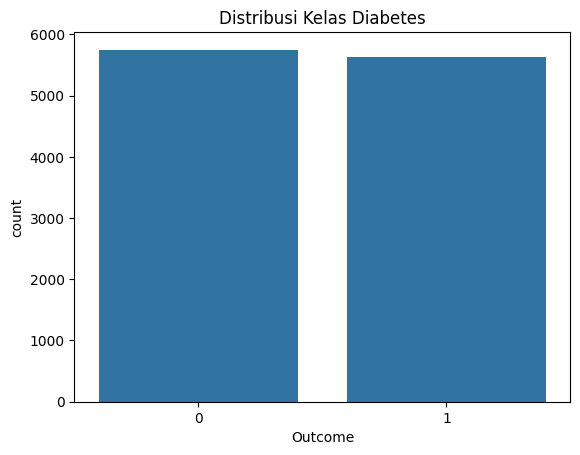

In [50]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Kelas Diabetes')
plt.show()


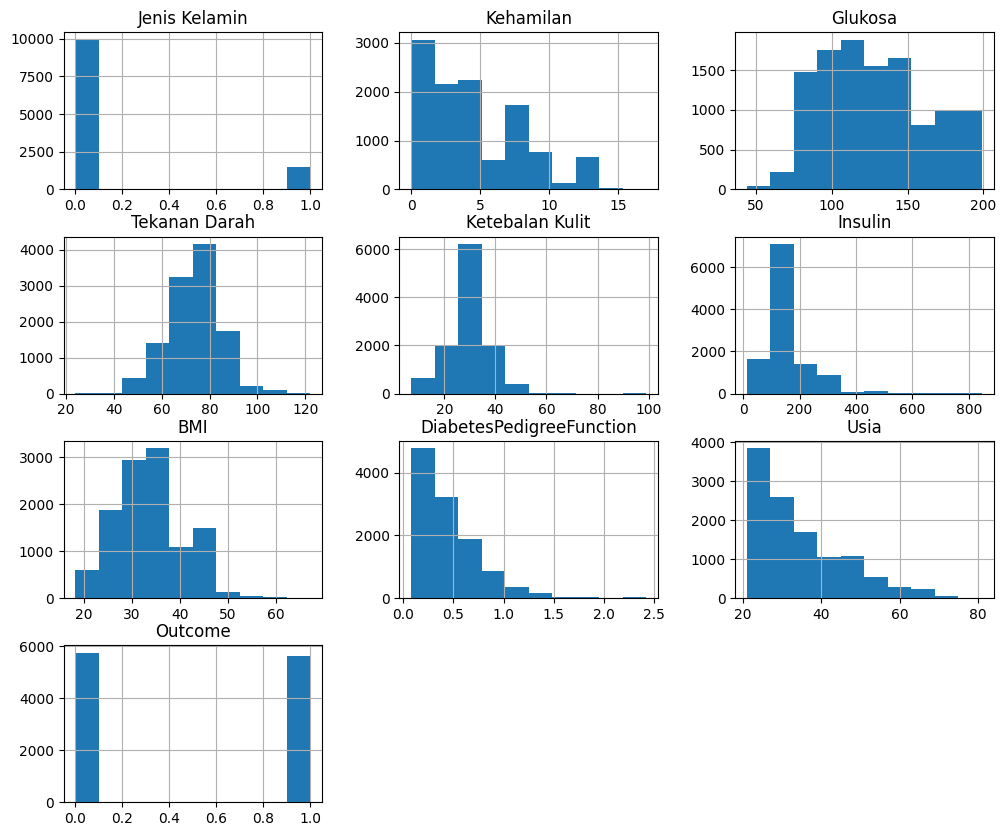

In [51]:
df.hist(figsize=(12,10))
plt.show()


In [52]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.2,
random_state=42,
stratify=y
)

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    cv=3,
    verbose=2
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

svm_model = grid.best_estimator_

Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   5.5s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.5s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   3.6s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   4.2s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   2.0s
[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   2.0s
[CV] END ...........................C=1, gamma=1,

In [56]:
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [57]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

In [59]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [60]:
y_pred_rf = rf_model.predict(X_test)

In [61]:
acc_svm = accuracy_score(y_test, y_pred_svm)
acc_rf = accuracy_score(y_test, y_pred_rf)
print('Accuracy SVM :', acc_svm)
print('Accuracy RF :', acc_rf)


Accuracy SVM : 0.9806678383128296
Accuracy RF : 0.8703866432337434


In [62]:
precision_svm = precision_score(y_test, y_pred_svm)
precision_rf = precision_score(y_test, y_pred_rf)

In [63]:
recall_svm = recall_score(y_test, y_pred_svm)
recall_rf = recall_score(y_test, y_pred_rf)


In [64]:
f1_svm = f1_score(y_test, y_pred_svm)
f1_rf = f1_score(y_test, y_pred_rf)

In [65]:
print(classification_report(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1150
           1       0.99      0.97      0.98      1126

    accuracy                           0.98      2276
   macro avg       0.98      0.98      0.98      2276
weighted avg       0.98      0.98      0.98      2276

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1150
           1       0.89      0.84      0.87      1126

    accuracy                           0.87      2276
   macro avg       0.87      0.87      0.87      2276
weighted avg       0.87      0.87      0.87      2276



In [66]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_rf = confusion_matrix(y_test, y_pred_rf)

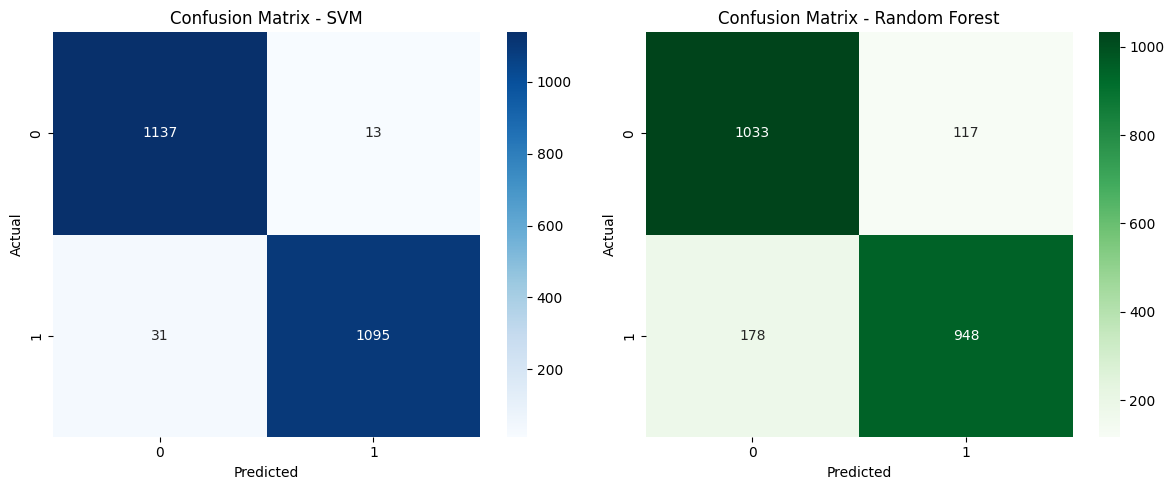

In [67]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.subplot(1,2,2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


In [68]:
svm_probs = svm_model.predict_proba(X_test_scaled)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:,1]


In [69]:
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

In [70]:
auc_svm = roc_auc_score(y_test, svm_probs)
auc_rf = roc_auc_score(y_test, rf_probs)


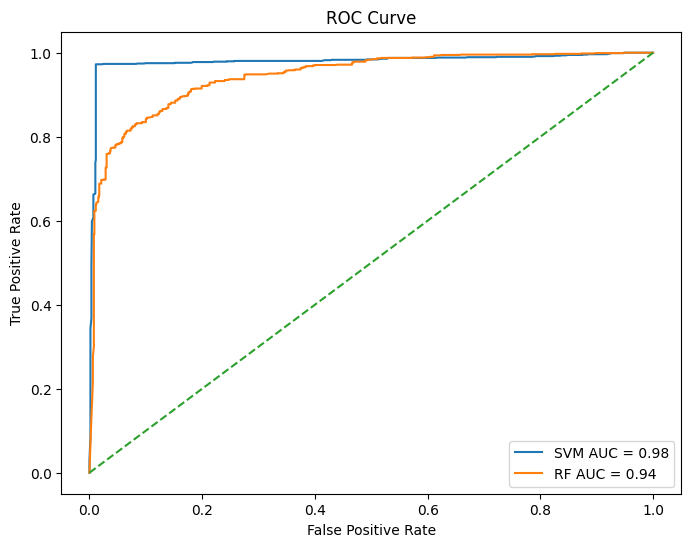

In [71]:
plt.figure(figsize=(8,6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM AUC = {auc_svm:.2f}')
plt.plot(fpr_rf, tpr_rf, label=f'RF AUC = {auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [72]:
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
'Feature': X.columns,
'Importance': importance
}).sort_values(by='Importance', ascending=False)
print(feature_importance)

                    Feature  Importance
2                   Glukosa    0.405931
6                       BMI    0.173547
8                      Usia    0.140058
1                 Kehamilan    0.097810
5                   Insulin    0.070733
7  DiabetesPedigreeFunction    0.053757
3             Tekanan Darah    0.030703
4           Ketebalan Kulit    0.025977
0             Jenis Kelamin    0.001484


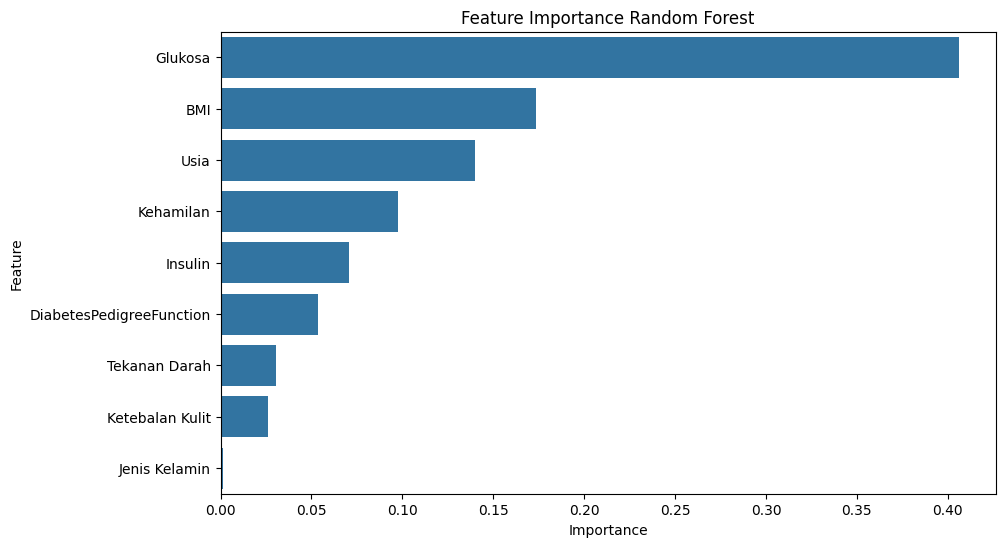

In [73]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)
plt.title('Feature Importance Random Forest')
plt.show()

In [74]:
train_acc_rf = accuracy_score(
y_train,
rf_model.predict(X_train)
)
test_acc_rf = accuracy_score(
y_test,
y_pred_rf
)
print('Train Accuracy RF :', train_acc_rf)
print('Test Accuracy RF :', test_acc_rf)


Train Accuracy RF : 0.8672527472527473
Test Accuracy RF : 0.8703866432337434


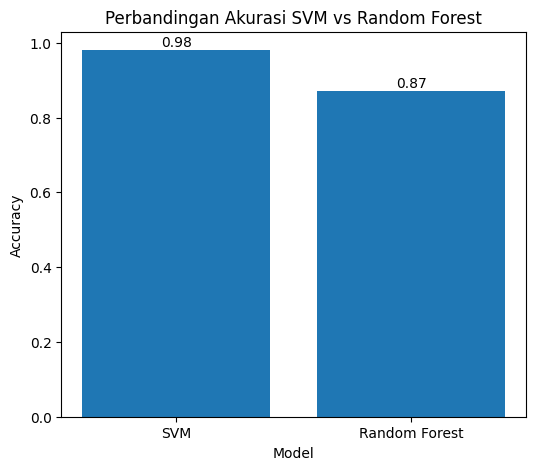

In [75]:
models = ['SVM', 'Random Forest']
accuracies = [acc_svm, acc_rf]
plt.figure(figsize=(6,5))
plt.bar(models, accuracies)
plt.title('Perbandingan Akurasi SVM vs Random Forest')
plt.xlabel('Model')
plt.ylabel('Accuracy')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.show()
